# Orosco Driver Drowsiness Preprocessing

This notebook converts the Orosco raw EDF recordings into Cui-style matrices for classification:

- `X`: EEG windows, shaped `(samples, channels, time)`
- `Y`: binary labels, `0 = alert`, `1 = drowsy`
- `subjects`: subject IDs
- `trials`: trial IDs

Labeling rule:

- Drowsy windows come from the 10 seconds before each button-press event.
- Alert windows are at least 60 seconds away from any button-press event.
- Ambiguous windows near events are ignored.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd

mne.set_log_level("WARNING")

DATA_DIR = Path("dataset")
if not DATA_DIR.exists():
    DATA_DIR = Path("data/driver-drowsiness/orosco/dataset")

sfreq = 128
window_seconds = 3
stride_seconds = 3
drowsy_pre_event_seconds = 10
alert_exclusion_seconds = 60

window_samples = window_seconds * sfreq
stride_samples = stride_seconds * sfreq

eeg_channels = ["O1-Ref", "O2-Ref", "C3-Ref", "C4-Ref"]
label_names = {0: "alert", 1: "drowsy"}

rng = np.random.default_rng(42)


## Annotation Parser

The annotation EDF files contain many button-press timestamps, but MNE does not expose all of them as normal annotations. This parser reads the EDF annotation text directly and extracts every `Event` onset.

In [2]:
def parse_event_times(annotation_path):
    text = annotation_path.read_bytes().decode("latin1", errors="ignore")
    matches = re.findall(r"\+([0-9]+(?:\.[0-9]+)?)\x14(?:[^\x14]*\x14)?Event", text)
    return np.array([float(match) for match in matches], dtype=np.float32)


def parse_recording_id(signal_path):
    match = re.match(r"(\d+)([MF])_(\d+)\.edf", signal_path.name)
    subject = int(match.group(1))
    gender = match.group(2)
    trial = int(match.group(3))
    return subject, gender, trial


def window_overlaps_any(start_s, end_s, intervals):
    if len(intervals) == 0:
        return False
    return bool(np.any((start_s < intervals[:, 1]) & (end_s > intervals[:, 0])))

## Create Labeled Windows

In [3]:
all_windows = []
all_labels = []
all_subjects = []
all_trials = []
all_start_times = []
all_sources = []

recording_summaries = []

signal_paths = sorted(path for path in DATA_DIR.glob("*.edf") if not path.name.endswith("_annotations.edf"))
print(f"Using data directory: {DATA_DIR}")
print(f"Found {len(signal_paths)} EDF signal files")

if len(signal_paths) == 0:
    raise ValueError(f"No EDF signal files found in {DATA_DIR}")

for signal_path in signal_paths:
    annotation_path = signal_path.with_name(f"{signal_path.stem}_annotations.edf")
    event_times = parse_event_times(annotation_path)
    subject, gender, trial = parse_recording_id(signal_path)

    raw = mne.io.read_raw_edf(signal_path, preload=True, verbose="ERROR")
    raw.pick(eeg_channels)
    data = raw.get_data()  # channels x time, in MNE-scaled physical units

    drowsy_intervals = np.column_stack([
        np.maximum(event_times - drowsy_pre_event_seconds, 0),
        event_times,
    ])
    alert_exclusion_intervals = np.column_stack([
        np.maximum(event_times - alert_exclusion_seconds, 0),
        event_times + alert_exclusion_seconds,
    ])

    recording_alert = 0
    recording_drowsy = 0
    recording_ignored = 0

    for start_sample in range(0, data.shape[1] - window_samples + 1, stride_samples):
        end_sample = start_sample + window_samples
        start_s = start_sample / sfreq
        end_s = end_sample / sfreq

        is_drowsy = window_overlaps_any(start_s, end_s, drowsy_intervals)
        is_near_event = window_overlaps_any(start_s, end_s, alert_exclusion_intervals)

        if is_drowsy:
            label = 1
            recording_drowsy += 1
        elif not is_near_event:
            label = 0
            recording_alert += 1
        else:
            recording_ignored += 1
            continue

        all_windows.append(data[:, start_sample:end_sample].astype(np.float32))
        all_labels.append(label)
        all_subjects.append(subject)
        all_trials.append(trial)
        all_start_times.append(start_s)
        all_sources.append(signal_path.name)

    recording_summaries.append({
        "recording": signal_path.name,
        "subject": subject,
        "gender": gender,
        "trial": trial,
        "events": len(event_times),
        "duration_min": raw.n_times / sfreq / 60,
        "alert_windows": recording_alert,
        "drowsy_windows": recording_drowsy,
        "ignored_windows": recording_ignored,
    })

if len(all_windows) == 0:
    raise ValueError("No labeled windows were created. Check DATA_DIR, event parsing, and labeling parameters.")

X_all = np.stack(all_windows).astype(np.float32)
Y_all = np.array(all_labels, dtype=np.int64)
subjects_all = np.array(all_subjects, dtype=np.int64)
trials_all = np.array(all_trials, dtype=np.int64)
start_times_all = np.array(all_start_times, dtype=np.float32)
sources_all = np.array(all_sources)

summary = pd.DataFrame(recording_summaries)
display(summary)

print("X_all:", X_all.shape)
print("Y_all:", Y_all.shape, dict(zip(*np.unique(Y_all, return_counts=True))))
print("subjects_all:", subjects_all.shape)
print("trials_all:", trials_all.shape)

Using data directory: dataset
Found 20 EDF signal files


,recording,subject,gender,trial,events,duration_min,alert_windows,drowsy_windows,ignored_windows
0,01M_1.edf,1,M,1,26,121.75,1551,103,781
1,01M_2.edf,1,M,2,58,121.25,949,232,1244
2,02F_1.edf,2,F,1,37,123.00,1464,138,858
3,02F_2.edf,2,F,2,29,121.00,1590,114,716
4,03F_1.edf,3,F,1,86,121.75,705,341,1389
5,03F_2.edf,3,F,2,96,122.50,1133,375,942
6,04M_1.edf,4,M,1,36,115.50,1197,143,970
7,04M_2.edf,4,M,2,46,120.25,1036,184,1185
8,05M_1.edf,5,M,1,25,120.75,1556,96,763
9,05M_2.edf,5,M,2,39,120.75,1431,152,832


X_all: (33932, 4, 384)
Y_all: (33932,) {np.int64(0): np.int64(30750), np.int64(1): np.int64(3182)}
subjects_all: (33932,)
trials_all: (33932,)


## Balance Alert and Drowsy Classes

The raw windowing creates many more alert windows than drowsy windows. For a Cui-style first classification matrix, this cell downsamples alert windows to match the number of drowsy windows.

In [4]:
alert_indices = np.where(Y_all == 0)[0]
drowsy_indices = np.where(Y_all == 1)[0]

n_per_class = min(len(alert_indices), len(drowsy_indices))
if n_per_class == 0:
    raise ValueError(f"Cannot balance classes: alert={len(alert_indices)}, drowsy={len(drowsy_indices)}")
balanced_alert_indices = rng.choice(alert_indices, size=n_per_class, replace=False)
balanced_drowsy_indices = rng.choice(drowsy_indices, size=n_per_class, replace=False)
balanced_indices = np.concatenate([balanced_alert_indices, balanced_drowsy_indices])
rng.shuffle(balanced_indices)

X = X_all[balanced_indices]
Y = Y_all[balanced_indices]
subjects = subjects_all[balanced_indices]
trials = trials_all[balanced_indices]
start_times = start_times_all[balanced_indices]
sources = sources_all[balanced_indices]

print("Balanced X:", X.shape)
print("Balanced Y:", Y.shape, dict(zip(*np.unique(Y, return_counts=True))))
print("Subjects:", sorted(np.unique(subjects).tolist()))
print("Channels:", eeg_channels)
print("Window length:", X.shape[-1], "samples")

Balanced X: (6364, 4, 384)
Balanced Y: (6364,) {np.int64(0): np.int64(3182), np.int64(1): np.int64(3182)}
Subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Channels: ['O1-Ref', 'O2-Ref', 'C3-Ref', 'C4-Ref']
Window length: 384 samples


## Label Summary

In [5]:
balanced_summary = pd.DataFrame({
    "subject": subjects,
    "trial": trials,
    "label": Y,
    "state": [label_names[label] for label in Y],
    "source": sources,
    "start_time_s": start_times,
})

display(balanced_summary.head())
display(pd.crosstab(balanced_summary["subject"], balanced_summary["state"]))
display(pd.crosstab(balanced_summary["source"], balanced_summary["state"]))

,subject,trial,label,state,source,start_time_s
0,1,1,0,alert,01M_1.edf,5556.0
1,3,2,1,drowsy,03F_2.edf,1128.0
2,3,2,1,drowsy,03F_2.edf,2274.0
3,7,2,1,drowsy,07F_2.edf,3708.0
4,10,1,0,alert,10M_1.edf,6999.0


state,alert,drowsy
subject,,
1,222,335
2,372,252
3,168,716
4,232,327
5,300,248
6,365,206
7,143,979
8,425,49
9,489,28


state,alert,drowsy
source,,
01M_1.edf,143,103
01M_2.edf,79,232
02F_1.edf,179,138
02F_2.edf,193,114
03F_1.edf,66,341
03F_2.edf,102,375
04M_1.edf,113,143
04M_2.edf,119,184
05M_1.edf,151,96


## Plot Labeled Snapshots

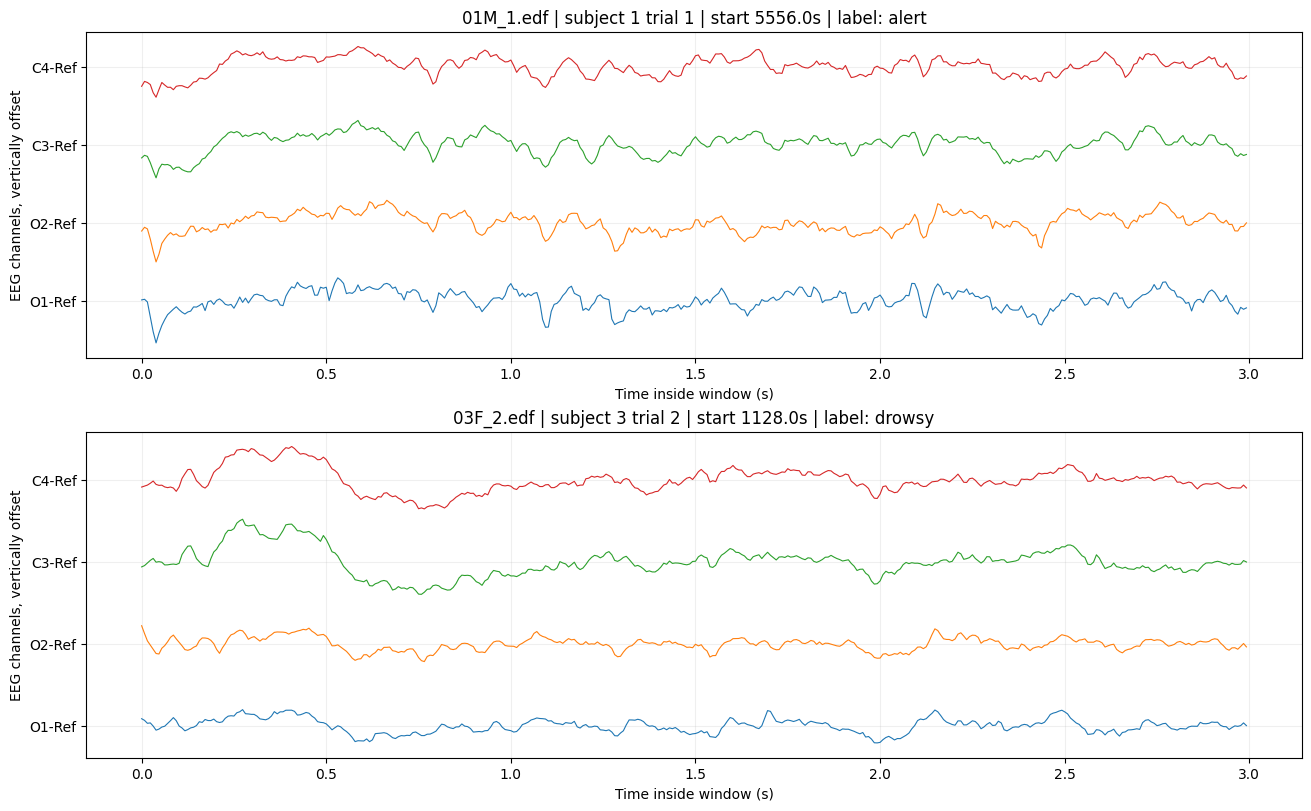

In [6]:
def plot_window(index, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 4))

    window = X[index]
    times = np.arange(window.shape[1]) / sfreq
    ptp = np.ptp(window, axis=1)
    offset_step = max(np.percentile(ptp, 75) * 1.25, 1e-6)
    offsets = np.arange(window.shape[0]) * offset_step

    for channel_idx, trace in enumerate(window):
        ax.plot(times, trace + offsets[channel_idx], linewidth=0.8)

    state = label_names[int(Y[index])]
    ax.set_title(
        f"{sources[index]} | subject {subjects[index]} trial {trials[index]} | "
        f"start {start_times[index]:.1f}s | label: {state}"
    )
    ax.set_xlabel("Time inside window (s)")
    ax.set_ylabel("EEG channels, vertically offset")
    ax.set_yticks(offsets)
    ax.set_yticklabels(eeg_channels)
    ax.grid(alpha=0.2)
    return ax


alert_example = int(np.where(Y == 0)[0][0])
drowsy_example = int(np.where(Y == 1)[0][0])

fig, axes = plt.subplots(2, 1, figsize=(13, 8), constrained_layout=True)
plot_window(alert_example, axes[0])
plot_window(drowsy_example, axes[1])
plt.show()

## Save Windowed Dataset

The saved `.npz` file can be loaded by future training notebooks without reparsing all EDF files.

In [7]:
output_path = DATA_DIR / "orosco_windowed_balanced.npz"

np.savez_compressed(
    output_path,
    X=X,
    Y=Y,
    subjects=subjects,
    trials=trials,
    start_times=start_times,
    sources=sources,
    channels=np.array(eeg_channels),
    sfreq=np.array(sfreq),
    window_seconds=np.array(window_seconds),
    label_names=np.array(["alert", "drowsy"]),
)

print(f"Saved {output_path}")

Saved dataset/orosco_windowed_balanced.npz
